## Scraping Data

In [5]:
!pip install google-play-scraper

from google_play_scraper import reviews, Sort
import pandas as pd
import numpy as np

app_id = 'app.signal.id'

def get_reviews(app_id, lang='id', count=2000, sort=Sort.NEWEST, filter_score_with=None, filter_device_with=None, continuation_token=None):
    try:
        result, continuation_token = reviews(
            app_id,
            lang=lang,
            country='id',
            sort=sort,
            count=count,
            filter_score_with=filter_score_with,
            filter_device_with=filter_device_with,
            continuation_token=continuation_token
        )
        return result, continuation_token
    except Exception as e:
        print("Error:", e)
        return None, None

# Ambil reviews
reviews_data, continuation_token = get_reviews(app_id)

# Jika berhasil, langsung tampilkan DataFrame
if reviews_data is not None:
    print("Jumlah ulasan:", len(reviews_data))
    data_scraping = pd.DataFrame(reviews_data)
    display(data_scraping.head(10))  # langsung tampilkan 10 teratas
else:
    print("Tidak dapat mengambil ulasan.")


Jumlah ulasan: 2000


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,17757d29-7836-48d3-b3c4-c8fa573f845f,Zidni Auliara,https://play-lh.googleusercontent.com/a-/ALV-U...,aplikasi korup!!!,1,0,None,2026-04-21 15:17:25,None,NaT,None
1,8997a2a2-efba-49c2-a1e2-e8813e9ec986,Antoni Sikumbang,https://play-lh.googleusercontent.com/a-/ALV-U...,sangat memudahkan dan tidak buang waktu dan te...,5,0,2.1.1,2026-04-21 14:33:40,"Hai Sahabat SIGNAL, Terima kasih atas ulasanny...",2026-04-22 01:33:08,2.1.1
2,8cee5801-73f0-41b5-88a3-ff6d65a3ed9d,Muji Anto,https://play-lh.googleusercontent.com/a-/ALV-U...,"Sangat membantu, efisien, cepat",5,0,None,2026-04-21 13:03:53,"Hai Sahabat SIGNAL, Terima kasih atas ulasanny...",2026-04-22 01:41:05,None
3,8cf99a88-0473-427a-8bc1-49f67a616158,Nisa Nisa,https://play-lh.googleusercontent.com/a/ACg8oc...,"opsi pembayarannya gak ada yang bisa, suruh ve...",1,0,2.1.1,2026-04-21 12:22:56,"Hai Sahabat SIGNAL, Mohon maaf atas kendala te...",2026-04-22 01:55:38,2.1.1
4,63b23155-057c-4c37-9a73-614984661dfa,Asya Elisabeth,https://play-lh.googleusercontent.com/a-/ALV-U...,gk guna.....,1,0,None,2026-04-21 12:08:04,None,NaT,None
5,e2328df9-b8ad-4ef8-8efd-45544c427b94,hebron daniel,https://play-lh.googleusercontent.com/a/ACg8oc...,"Aneh, sudah daftar tapi tidak bisa cek.",1,0,2.1.1,2026-04-21 11:11:51,"Hai Sahabat SIGNAL, Mohon maaf atas kendala te...",2026-04-22 01:59:31,2.1.1
6,18c55542-3d82-427b-8a2a-a344190bbff6,Mery Mery,https://play-lh.googleusercontent.com/a/ACg8oc...,mantap dah gak perlu cape2 ke samsat,5,0,None,2026-04-21 10:44:53,"Hai Sahabat SIGNAL, Terima kasih atas ulasanny...",2026-04-22 01:40:12,None
7,81cbe8e1-ad69-42e8-b4c0-c04838249086,Dwi Agus,https://play-lh.googleusercontent.com/a/ACg8oc...,memakai brimo tak ada wilayah DIY. jadi binggu...,5,0,2.1.1,2026-04-21 10:43:21,None,NaT,2.1.1
8,e6972a58-8da9-49b6-96ad-eb6b0437a141,Hilman Nurdin,https://play-lh.googleusercontent.com/a/ACg8oc...,sangat membantu bagi yg sibuk dengan pekerjaan...,5,0,2.0.0,2026-04-21 09:19:46,"Hai Sahabat SIGNAL, Terima kasih atas ulasanny...",2026-04-22 01:36:30,2.0.0
9,ccb1d28b-2e4d-4fd0-8c6e-a77b985108b3,imam mardiyanto,https://play-lh.googleusercontent.com/a-/ALV-U...,susah betul mau verifikasi data,1,0,2.1.1,2026-04-21 09:08:37,"Hai Sahabat SIGNAL, Mohon maaf atas kendala ve...",2026-04-22 02:00:30,2.1.1


In [6]:
import csv

def export_to_csv(reviews_list, file_name="scraping_samsat.csv"):
    if reviews_list:
        fieldnames = ["id", "username", "rating", "review", "date"]

        with open(file_name, mode="w", newline="", encoding="utf-8") as csv_file:
            writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
            writer.writeheader()

            for review in reviews_list:
                writer.writerow(
                    {
                        "id": review["reviewId"],
                        "username": review["userName"],
                        "rating": review["score"],
                        "review": review["content"],
                        "date": review["at"],
                    }
                )

        print(f"Successfully Export Data '{file_name}'")
    else:
        print(f"Data Export Not Found")


# Memanggil fungsi dengan data reviews
export_to_csv(reviews_data)

Successfully Export Data 'scraping_samsat.csv'


## Filter Data

In [7]:
import pandas as pd

data = pd.read_csv("scraping_samsat.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        2000 non-null   object
 1   username  2000 non-null   object
 2   rating    2000 non-null   int64 
 3   review    2000 non-null   object
 4   date      2000 non-null   object
dtypes: int64(1), object(4)
memory usage: 78.3+ KB


In [8]:
df = pd.DataFrame(data[['username', 'rating', 'review']])
df.head(10)

,username,rating,review
0,Zidni Auliara,1,aplikasi korup!!!
1,Antoni Sikumbang,5,sangat memudahkan dan tidak buang waktu dan te...
2,Muji Anto,5,"Sangat membantu, efisien, cepat"
3,Nisa Nisa,1,"opsi pembayarannya gak ada yang bisa, suruh ve..."
4,Asya Elisabeth,1,gk guna.....
5,hebron daniel,1,"Aneh, sudah daftar tapi tidak bisa cek."
6,Mery Mery,5,mantap dah gak perlu cape2 ke samsat
7,Dwi Agus,5,memakai brimo tak ada wilayah DIY. jadi binggu...
8,Hilman Nurdin,5,sangat membantu bagi yg sibuk dengan pekerjaan...
9,imam mardiyanto,1,susah betul mau verifikasi data


### Menghapus Duplikat dan Data Kosong

In [9]:
df.drop_duplicates(subset="review", keep='first', inplace=True)

In [10]:
df['review'] = df['review'].astype('string').str.strip()

In [11]:
df = df.dropna(subset=['review'])

In [12]:
df = df[(df['review'] != "") & (~df['review'].str.fullmatch(r'\s*'))]

In [13]:
df = df.drop_duplicates(subset=['review'], keep='first')

In [14]:
df = df[df['review'].str.len() >= 3].reset_index(drop=True)

In [15]:
df.info(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1887 entries, 0 to 1886
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   username  1887 non-null   object
 1   rating    1887 non-null   int64 
 2   review    1887 non-null   string
dtypes: int64(1), object(1), string(1)
memory usage: 44.4+ KB


## Text Processing

### Cleaning

In [16]:
import re
import pandas as pd

# Fungsi untuk menghapus URL
def remove_URL(cleaning):
    if cleaning is not None and isinstance(cleaning, str):
        url = re.compile(r'https?://\S+|www\.\S+')
        return url.sub(r'', cleaning)
    return cleaning

# Fungsi untuk menghapus HTML
def remove_html(cleaning):
    if cleaning is not None and isinstance(cleaning, str):
        html = re.compile(r'<.*?>')
        return html.sub(r'', cleaning)
    return cleaning

# Fungsi untuk menghapus emoji
def remove_emoji(cleaning):
    if cleaning is not None and isinstance(cleaning, str):
        emoji_pattern = re.compile("["
            u"\U0001F600-\U0001F64F"
            u"\U0001F300-\U0001F5FF"
            u"\U0001F680-\U0001F6FF"
            u"\U0001F700-\U0001F77F"
            u"\U0001F780-\U0001F7FF"
            u"\U0001F800-\U0001F8FF"
            u"\U0001F900-\U0001F9FF"
            u"\U0001FA00-\U0001FA6F"
            u"\U0001FA70-\U0001FAFF"
            u"\U0001F1E0-\U0001F1FF"
            "]+", flags=re.UNICODE)
        return emoji_pattern.sub(r'', cleaning)
    return cleaning

# Fungsi untuk menghapus simbol (selain huruf/angka/spasi)
def remove_symbols(cleaning):
    if cleaning is not None and isinstance(cleaning, str):
        return re.sub(r'[^a-zA-Z0-9\s]', ' ', cleaning)
    return cleaning

# Fungsi untuk menghapus angka
def remove_numbers(cleaning):
    if cleaning is not None and isinstance(cleaning, str):
        return re.sub(r'\d', '', cleaning)
    return cleaning

# Fungsi untuk menangani emotikon klasik (:) ;-) :D :P)
def remove_emoticon(cleaning):
    if cleaning is not None and isinstance(cleaning, str):
        emoticons = re.findall(r'(?::|;|=)(?:-)?(?:\)|\(|D|P)', cleaning)
        text = re.sub(r'[\W]+', ' ', cleaning)
        emoticon_str = ' '.join(e.replace('-', '') for e in emoticons)
        return (text + ' ' + emoticon_str).strip()
    return cleaning

# Fungsi normalisasi spasi & tanda baca (pola 1–8)
def normalize_spacing(cleaning):
    if cleaning is not None and isinstance(cleaning, str):
        cleaning = re.sub(r'\s+,', ' ', cleaning)
        cleaning = re.sub(r'([A-Za-z])\.([A-Za-z])', r'\1 \2', cleaning)
        cleaning = re.sub(r'\.{2,}', ' ', cleaning)
        cleaning = re.sub(r'\s+([?.!,])', r'\1', cleaning)
        cleaning = re.sub(r'([A-Za-z]),([A-Za-z])', r'\1 \2', cleaning)
        cleaning = re.sub(r'([A-Za-z])\-([A-Za-z])', r'\1 \2', cleaning)
        cleaning = re.sub(r'\s+', ' ', cleaning)
        cleaning = re.sub(r'[\"\'\(\)\[\]]', '', cleaning)
        return cleaning.strip()
    return cleaning

# Membuat Kolom Cleaning
df['cleaning'] = df['review'].apply(
    lambda x: normalize_spacing(remove_emoticon(remove_numbers(remove_symbols(remove_emoji(remove_html(remove_URL(x))))))))

df.head(10)

,username,rating,review,cleaning
0,Zidni Auliara,1,aplikasi korup!!!,aplikasi korup
1,Antoni Sikumbang,5,sangat memudahkan dan tidak buang waktu dan te...,sangat memudahkan dan tidak buang waktu dan te...
2,Muji Anto,5,"Sangat membantu, efisien, cepat",Sangat membantu efisien cepat
3,Nisa Nisa,1,"opsi pembayarannya gak ada yang bisa, suruh ve...",opsi pembayarannya gak ada yang bisa suruh ver...
4,Asya Elisabeth,1,gk guna.....,gk guna
5,hebron daniel,1,"Aneh, sudah daftar tapi tidak bisa cek.",Aneh sudah daftar tapi tidak bisa cek
6,Mery Mery,5,mantap dah gak perlu cape2 ke samsat,mantap dah gak perlu cape ke samsat
7,Dwi Agus,5,memakai brimo tak ada wilayah DIY. jadi binggu...,memakai brimo tak ada wilayah DIY jadi binggun...
8,Hilman Nurdin,5,sangat membantu bagi yg sibuk dengan pekerjaan...,sangat membantu bagi yg sibuk dengan pekerjaan...
9,imam mardiyanto,1,susah betul mau verifikasi data,susah betul mau verifikasi data


### Case Folding

In [17]:
import re

def case_folding(df, text_field, new_text_field_name):
    df[new_text_field_name] = df[text_field].apply(
        lambda elem: elem.lower() if isinstance(elem, str) else elem
    )
    return df

df = case_folding(df, 'cleaning', 'case_folding')
df.head(10)

,username,rating,review,cleaning,case_folding
0,Zidni Auliara,1,aplikasi korup!!!,aplikasi korup,aplikasi korup
1,Antoni Sikumbang,5,sangat memudahkan dan tidak buang waktu dan te...,sangat memudahkan dan tidak buang waktu dan te...,sangat memudahkan dan tidak buang waktu dan te...
2,Muji Anto,5,"Sangat membantu, efisien, cepat",Sangat membantu efisien cepat,sangat membantu efisien cepat
3,Nisa Nisa,1,"opsi pembayarannya gak ada yang bisa, suruh ve...",opsi pembayarannya gak ada yang bisa suruh ver...,opsi pembayarannya gak ada yang bisa suruh ver...
4,Asya Elisabeth,1,gk guna.....,gk guna,gk guna
5,hebron daniel,1,"Aneh, sudah daftar tapi tidak bisa cek.",Aneh sudah daftar tapi tidak bisa cek,aneh sudah daftar tapi tidak bisa cek
6,Mery Mery,5,mantap dah gak perlu cape2 ke samsat,mantap dah gak perlu cape ke samsat,mantap dah gak perlu cape ke samsat
7,Dwi Agus,5,memakai brimo tak ada wilayah DIY. jadi binggu...,memakai brimo tak ada wilayah DIY jadi binggun...,memakai brimo tak ada wilayah diy jadi binggun...
8,Hilman Nurdin,5,sangat membantu bagi yg sibuk dengan pekerjaan...,sangat membantu bagi yg sibuk dengan pekerjaan...,sangat membantu bagi yg sibuk dengan pekerjaan...
9,imam mardiyanto,1,susah betul mau verifikasi data,susah betul mau verifikasi data,susah betul mau verifikasi data


### Normalization

In [18]:
!wget -O kamuskatabaku.xlsx https://raw.githubusercontent.com/hilmiammar/analisis-sentimen/master/kamuskatabaku.xlsx

import pandas as pd

df_normalization = pd.read_excel("kamuskatabaku.xlsx")
df_normalization = df_normalization.rename(columns={
    'tidak_baku': 'non_standard',
    'kata_baku': 'standard_word'
})

if not {'non_standard', 'standard_word'}.issubset(df_normalization.columns):
    raise ValueError("Excel must have columns: 'non_standard' and 'standard_word' "
                     "(or old 'tidak_baku' & 'kata_baku').")

df_normalization = df_normalization.dropna(subset=['non_standard', 'standard_word']).copy()
df_normalization['non_standard'] = df_normalization['non_standard'].astype(str).str.strip().str.lower()
df_normalization['standard_word'] = df_normalization['standard_word'].astype(str).str.strip().str.lower()
df_normalization = df_normalization.drop_duplicates(subset=['non_standard'], keep='first')

nonstandard_dict = dict(zip(df_normalization['non_standard'], df_normalization['standard_word']))

def normalization(text: str, mapping: dict) -> str:
    if not isinstance(text, str):
        return ""
    tokens = text.split()
    out = []
    for tok in tokens:
        repl = mapping.get(tok.lower())
        out.append(repl if isinstance(repl, str) and repl.isalpha() else tok)
    return " ".join(out)

df['normalization'] = df['case_folding'].apply(lambda t: normalization(t, nonstandard_dict))

df.head(10)

--2026-04-22 17:41:04--  https://raw.githubusercontent.com/hilmiammar/analisis-sentimen/master/kamuskatabaku.xlsx
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 570125 (557K) [application/octet-stream]
Saving to: ‘kamuskatabaku.xlsx’

kamuskatabaku.xlsx  100%[===================>] 556.76K  --.-KB/s    in 0.03s   

2026-04-22 17:41:04 (18.4 MB/s) - ‘kamuskatabaku.xlsx’ saved [570125/570125]



,username,rating,review,cleaning,case_folding,normalization
0,Zidni Auliara,1,aplikasi korup!!!,aplikasi korup,aplikasi korup,aplikasi korup
1,Antoni Sikumbang,5,sangat memudahkan dan tidak buang waktu dan te...,sangat memudahkan dan tidak buang waktu dan te...,sangat memudahkan dan tidak buang waktu dan te...,sangat memudahkan dan tidak buang waktu dan te...
2,Muji Anto,5,"Sangat membantu, efisien, cepat",Sangat membantu efisien cepat,sangat membantu efisien cepat,sangat membantu efisien cepat
3,Nisa Nisa,1,"opsi pembayarannya gak ada yang bisa, suruh ve...",opsi pembayarannya gak ada yang bisa suruh ver...,opsi pembayarannya gak ada yang bisa suruh ver...,pilihan pembayarannya tidak ada yang bisa suru...
4,Asya Elisabeth,1,gk guna.....,gk guna,gk guna,tidak guna
5,hebron daniel,1,"Aneh, sudah daftar tapi tidak bisa cek.",Aneh sudah daftar tapi tidak bisa cek,aneh sudah daftar tapi tidak bisa cek,aneh sudah daftar tetapi tidak bisa cek
6,Mery Mery,5,mantap dah gak perlu cape2 ke samsat,mantap dah gak perlu cape ke samsat,mantap dah gak perlu cape ke samsat,mantap sudah tidak perlu capek ke samsat
7,Dwi Agus,5,memakai brimo tak ada wilayah DIY. jadi binggu...,memakai brimo tak ada wilayah DIY jadi binggun...,memakai brimo tak ada wilayah diy jadi binggun...,memakai brimo tidak ada wilayah diy jadi bingg...
8,Hilman Nurdin,5,sangat membantu bagi yg sibuk dengan pekerjaan...,sangat membantu bagi yg sibuk dengan pekerjaan...,sangat membantu bagi yg sibuk dengan pekerjaan...,sangat membantu bagi yang sibuk dengan pekerja...
9,imam mardiyanto,1,susah betul mau verifikasi data,susah betul mau verifikasi data,susah betul mau verifikasi data,susah betul mau verifikasi data


### Tokenizing

In [19]:
import nltk
nltk.download(['punkt', 'punkt_tab'])

from nltk.tokenize import word_tokenize

def tokenize(text):
    if isinstance(text, str):
        return word_tokenize(text)
    else:
        return []

df['tokenize'] = df['normalization'].apply(tokenize)
df.head(10)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,username,rating,review,cleaning,case_folding,normalization,tokenize
0,Zidni Auliara,1,aplikasi korup!!!,aplikasi korup,aplikasi korup,aplikasi korup,"[aplikasi, korup]"
1,Antoni Sikumbang,5,sangat memudahkan dan tidak buang waktu dan te...,sangat memudahkan dan tidak buang waktu dan te...,sangat memudahkan dan tidak buang waktu dan te...,sangat memudahkan dan tidak buang waktu dan te...,"[sangat, memudahkan, dan, tidak, buang, waktu,..."
2,Muji Anto,5,"Sangat membantu, efisien, cepat",Sangat membantu efisien cepat,sangat membantu efisien cepat,sangat membantu efisien cepat,"[sangat, membantu, efisien, cepat]"
3,Nisa Nisa,1,"opsi pembayarannya gak ada yang bisa, suruh ve...",opsi pembayarannya gak ada yang bisa suruh ver...,opsi pembayarannya gak ada yang bisa suruh ver...,pilihan pembayarannya tidak ada yang bisa suru...,"[pilihan, pembayarannya, tidak, ada, yang, bis..."
4,Asya Elisabeth,1,gk guna.....,gk guna,gk guna,tidak guna,"[tidak, guna]"
5,hebron daniel,1,"Aneh, sudah daftar tapi tidak bisa cek.",Aneh sudah daftar tapi tidak bisa cek,aneh sudah daftar tapi tidak bisa cek,aneh sudah daftar tetapi tidak bisa cek,"[aneh, sudah, daftar, tetapi, tidak, bisa, cek]"
6,Mery Mery,5,mantap dah gak perlu cape2 ke samsat,mantap dah gak perlu cape ke samsat,mantap dah gak perlu cape ke samsat,mantap sudah tidak perlu capek ke samsat,"[mantap, sudah, tidak, perlu, capek, ke, samsat]"
7,Dwi Agus,5,memakai brimo tak ada wilayah DIY. jadi binggu...,memakai brimo tak ada wilayah DIY jadi binggun...,memakai brimo tak ada wilayah diy jadi binggun...,memakai brimo tidak ada wilayah diy jadi bingg...,"[memakai, brimo, tidak, ada, wilayah, diy, jad..."
8,Hilman Nurdin,5,sangat membantu bagi yg sibuk dengan pekerjaan...,sangat membantu bagi yg sibuk dengan pekerjaan...,sangat membantu bagi yg sibuk dengan pekerjaan...,sangat membantu bagi yang sibuk dengan pekerja...,"[sangat, membantu, bagi, yang, sibuk, dengan, ..."
9,imam mardiyanto,1,susah betul mau verifikasi data,susah betul mau verifikasi data,susah betul mau verifikasi data,susah betul mau verifikasi data,"[susah, betul, mau, verifikasi, data]"


### Stopword Removal

In [21]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = stopwords.words('indonesian')

def remove_stopwords(text):
    return [word for word in text if word not in stop_words]

df['stopword_removal'] = df['tokenize'].apply(lambda x: remove_stopwords(x))
df.head(10)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,username,rating,review,cleaning,case_folding,normalization,tokenize,stopword_removal
0,Zidni Auliara,1,aplikasi korup!!!,aplikasi korup,aplikasi korup,aplikasi korup,"[aplikasi, korup]","[aplikasi, korup]"
1,Antoni Sikumbang,5,sangat memudahkan dan tidak buang waktu dan te...,sangat memudahkan dan tidak buang waktu dan te...,sangat memudahkan dan tidak buang waktu dan te...,sangat memudahkan dan tidak buang waktu dan te...,"[sangat, memudahkan, dan, tidak, buang, waktu,...","[memudahkan, buang, tenaga, menunggu, rumah, s..."
2,Muji Anto,5,"Sangat membantu, efisien, cepat",Sangat membantu efisien cepat,sangat membantu efisien cepat,sangat membantu efisien cepat,"[sangat, membantu, efisien, cepat]","[membantu, efisien, cepat]"
3,Nisa Nisa,1,"opsi pembayarannya gak ada yang bisa, suruh ve...",opsi pembayarannya gak ada yang bisa suruh ver...,opsi pembayarannya gak ada yang bisa suruh ver...,pilihan pembayarannya tidak ada yang bisa suru...,"[pilihan, pembayarannya, tidak, ada, yang, bis...","[pilihan, pembayarannya, suruh, verivikasi, ak..."
4,Asya Elisabeth,1,gk guna.....,gk guna,gk guna,tidak guna,"[tidak, guna]",[]
5,hebron daniel,1,"Aneh, sudah daftar tapi tidak bisa cek.",Aneh sudah daftar tapi tidak bisa cek,aneh sudah daftar tapi tidak bisa cek,aneh sudah daftar tetapi tidak bisa cek,"[aneh, sudah, daftar, tetapi, tidak, bisa, cek]","[aneh, daftar, cek]"
6,Mery Mery,5,mantap dah gak perlu cape2 ke samsat,mantap dah gak perlu cape ke samsat,mantap dah gak perlu cape ke samsat,mantap sudah tidak perlu capek ke samsat,"[mantap, sudah, tidak, perlu, capek, ke, samsat]","[mantap, capek, samsat]"
7,Dwi Agus,5,memakai brimo tak ada wilayah DIY. jadi binggu...,memakai brimo tak ada wilayah DIY jadi binggun...,memakai brimo tak ada wilayah diy jadi binggun...,memakai brimo tidak ada wilayah diy jadi bingg...,"[memakai, brimo, tidak, ada, wilayah, diy, jad...","[memakai, brimo, wilayah, diy, binggung, atm, ..."
8,Hilman Nurdin,5,sangat membantu bagi yg sibuk dengan pekerjaan...,sangat membantu bagi yg sibuk dengan pekerjaan...,sangat membantu bagi yg sibuk dengan pekerjaan...,sangat membantu bagi yang sibuk dengan pekerja...,"[sangat, membantu, bagi, yang, sibuk, dengan, ...","[membantu, sibuk, pekerjaan, ya, tinggal, klik..."
9,imam mardiyanto,1,susah betul mau verifikasi data,susah betul mau verifikasi data,susah betul mau verifikasi data,susah betul mau verifikasi data,"[susah, betul, mau, verifikasi, data]","[susah, verifikasi, data]"


### Stemming

In [22]:
!pip install Sastrawi

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.stem import PorterStemmer
from nltk.stem.snowball import SnowballStemmer

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemmed_wrapper(term: str) -> str:
    return stemmer.stem(term)

term_dict = {}
counter = 0

for document in df['stopword_removal']:
    for term in document:
        if term not in term_dict:
            term_dict[term] = ' '

print(len(term_dict))
print("------------------------")

for term in term_dict:
    term_dict[term] = stemmed_wrapper(term)
    counter += 1
    print(counter, ":", term, ":", term_dict[term])

print(term_dict)
print("------------------------")

def get_stemmed_term(document):
    return [term_dict[term] for term in document]

df['stemming'] = df['stopword_removal'].apply(
    lambda x: ' '.join(get_stemmed_term(x))
)

df.head(10)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.8 MB/s eta 0:00:00
2227
------------------------
1 : aplikasi : aplikasi
2 : korup : korup
3 : memudahkan : mudah
4 : buang : buang
5 : tenaga : tenaga
6 : menunggu : tunggu
7 : rumah : rumah
8 : stnk : stnk
9 : nyampek : nyampek
10 : membantu : bantu
11 : efisien : efisien
12 : cepat : cepat
13 : pilihan : pilih
14 : pembayarannya : bayar
15 : suruh : suruh
16 : verivikasi : verivikasi
17 : akun : akun
18 : klik : klik
19 : aneh : aneh
20 : daftar : daftar
21 : cek : cek
22 : mantap : mantap
23 : capek : capek
24 : samsat : samsat
25 : memakai : pakai
26 : brimo : brimo
27 : wilayah : wilayah
28 : diy : diy
29 : binggung : binggung
30 : atm : atm
31 : terbit : terbit
32 : pembuatan : buat
33 : rekening : rekening
34 : sibuk : sibuk
35 : pekerjaan : kerja
36 : ya : ya
37 : tinggal : tinggal
38 : alamat : alamat
39 : susah : susah
40 : verifikasi : verifikasi
41 : data : data
42 : giliran : gilir
43 : pembayaran : bayar
44 : d

,username,rating,review,cleaning,case_folding,normalization,tokenize,stopword_removal,stemming
0,Zidni Auliara,1,aplikasi korup!!!,aplikasi korup,aplikasi korup,aplikasi korup,"[aplikasi, korup]","[aplikasi, korup]",aplikasi korup
1,Antoni Sikumbang,5,sangat memudahkan dan tidak buang waktu dan te...,sangat memudahkan dan tidak buang waktu dan te...,sangat memudahkan dan tidak buang waktu dan te...,sangat memudahkan dan tidak buang waktu dan te...,"[sangat, memudahkan, dan, tidak, buang, waktu,...","[memudahkan, buang, tenaga, menunggu, rumah, s...",mudah buang tenaga tunggu rumah stnk nyampek
2,Muji Anto,5,"Sangat membantu, efisien, cepat",Sangat membantu efisien cepat,sangat membantu efisien cepat,sangat membantu efisien cepat,"[sangat, membantu, efisien, cepat]","[membantu, efisien, cepat]",bantu efisien cepat
3,Nisa Nisa,1,"opsi pembayarannya gak ada yang bisa, suruh ve...",opsi pembayarannya gak ada yang bisa suruh ver...,opsi pembayarannya gak ada yang bisa suruh ver...,pilihan pembayarannya tidak ada yang bisa suru...,"[pilihan, pembayarannya, tidak, ada, yang, bis...","[pilihan, pembayarannya, suruh, verivikasi, ak...",pilih bayar suruh verivikasi akun verivikasi klik
4,Asya Elisabeth,1,gk guna.....,gk guna,gk guna,tidak guna,"[tidak, guna]",[],
5,hebron daniel,1,"Aneh, sudah daftar tapi tidak bisa cek.",Aneh sudah daftar tapi tidak bisa cek,aneh sudah daftar tapi tidak bisa cek,aneh sudah daftar tetapi tidak bisa cek,"[aneh, sudah, daftar, tetapi, tidak, bisa, cek]","[aneh, daftar, cek]",aneh daftar cek
6,Mery Mery,5,mantap dah gak perlu cape2 ke samsat,mantap dah gak perlu cape ke samsat,mantap dah gak perlu cape ke samsat,mantap sudah tidak perlu capek ke samsat,"[mantap, sudah, tidak, perlu, capek, ke, samsat]","[mantap, capek, samsat]",mantap capek samsat
7,Dwi Agus,5,memakai brimo tak ada wilayah DIY. jadi binggu...,memakai brimo tak ada wilayah DIY jadi binggun...,memakai brimo tak ada wilayah diy jadi binggun...,memakai brimo tidak ada wilayah diy jadi bingg...,"[memakai, brimo, tidak, ada, wilayah, diy, jad...","[memakai, brimo, wilayah, diy, binggung, atm, ...",pakai brimo wilayah diy binggung atm terbit bu...
8,Hilman Nurdin,5,sangat membantu bagi yg sibuk dengan pekerjaan...,sangat membantu bagi yg sibuk dengan pekerjaan...,sangat membantu bagi yg sibuk dengan pekerjaan...,sangat membantu bagi yang sibuk dengan pekerja...,"[sangat, membantu, bagi, yang, sibuk, dengan, ...","[membantu, sibuk, pekerjaan, ya, tinggal, klik...",bantu sibuk kerja ya tinggal klik alamat rumah
9,imam mardiyanto,1,susah betul mau verifikasi data,susah betul mau verifikasi data,susah betul mau verifikasi data,susah betul mau verifikasi data,"[susah, betul, mau, verifikasi, data]","[susah, verifikasi, data]",susah verifikasi data


### Filter Data Setelah Pre-Processing

In [ ]:
df.head(10)

,username,rating,review,cleaning,case_folding,normalization,tokenize,stopword_removal,stemming
0,Abdullah Darussalam,5,Layanannya cepat dan mudah pengoperasiannya. M...,Layanannya cepat dan mudah pengoperasiannya Ma...,layanannya cepat dan mudah pengoperasiannya ma...,layanannya cepat dan mudah pengoperasiannya ma...,"[layanannya, cepat, dan, mudah, pengoperasiann...","[layanannya, cepat, mudah, pengoperasiannya]",layan cepat mudah operasi
1,Yungeska Malayu,5,Samsat mempermudah pengurusan pajak kendaraan ...,Samsat mempermudah pengurusan pajak kendaraan ...,samsat mempermudah pengurusan pajak kendaraan ...,samsat mempermudah pengurusan pajak kendaraan ...,"[samsat, mempermudah, pengurusan, pajak, kenda...","[samsat, mempermudah, pengurusan, pajak, kenda...",samsat mudah urus pajak kendara antri
2,Kakashi Indra,1,"udah 2x download pakai hp berbeda, daftar akun...",udah x download pakai hp berbeda daftar akun a...,udah x download pakai hp berbeda daftar akun a...,sudah kali unduh pakai hp berbeda daftar akun ...,"[sudah, kali, unduh, pakai, hp, berbeda, dafta...","[kali, unduh, pakai, hp, berbeda, daftar, akun...",kali unduh pakai hp beda daftar akun susah ban...
3,ANTON BORIEL,5,mantap,mantap,mantap,mantap,[mantap],[mantap],mantap
4,Masayu Motor,4,Mantap,Mantap,mantap,mantap,[mantap],[mantap],mantap
5,Aming Sudjana,5,pengalaman pertama begitu menegangkan karena k...,pengalaman pertama begitu menegangkan karena k...,pengalaman pertama begitu menegangkan karena k...,pengalaman pertama begitu menegangkan karena k...,"[pengalaman, pertama, begitu, menegangkan, kar...","[pengalaman, menegangkan, kurangnya, peneranga...",alam tegang kurang terang legaaaaa tujuh nanti
6,Andi Syamsu Natsir,5,"Recommended, No ribet, praktis",Recommended No ribet praktis,recommended no ribet praktis,recommended no ribet praktis,"[recommended, no, ribet, praktis]","[recommended, no, ribet, praktis]",recommended no ribet praktis
7,Vivi Nofita,5,mudah dan cepat,mudah dan cepat,mudah dan cepat,mudah dan cepat,"[mudah, dan, cepat]","[mudah, cepat]",mudah cepat
8,Sobat GADGET,5,mudah banget jdi gk kena calo lagi,mudah banget jdi gk kena calo lagi,mudah banget jdi gk kena calo lagi,mudah sekali jadi tidak kena calo lagi,"[mudah, sekali, jadi, tidak, kena, calo, lagi]","[mudah, kena, calo]",mudah kena calo
9,Dinna Fatumariana,5,knp aplikasi signal saya gak bisa ya tahun lal...,knp aplikasi signal saya gak bisa ya tahun lal...,knp aplikasi signal saya gak bisa ya tahun lal...,kenapa aplikasi jaringan aku tidak bisa ya tah...,"[kenapa, aplikasi, jaringan, aku, tidak, bisa,...","[aplikasi, jaringan, ya, perpanjang, stnk, apl...",aplikasi jaring ya panjang stnk aplikasi jarin...


In [23]:
df = df.dropna()

In [24]:
df.dropna(inplace=True)
df.dropna(axis=1, inplace=True)
df.drop_duplicates(inplace=True, subset=[col for col in df.columns if col not in ['tokenize', 'stopword_removal']])
df.replace(r'^\s*$', pd.NA, regex=True, inplace=True)
df.dropna(how='all', inplace=True)

In [25]:
df = df.dropna()

In [28]:
df.info(10)

<class 'pandas.core.frame.DataFrame'>
Index: 1743 entries, 0 to 1752
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   username          1743 non-null   object
 1   rating            1743 non-null   int64 
 2   review            1743 non-null   string
 3   cleaning          1743 non-null   object
 4   case_folding      1743 non-null   object
 5   normalization     1743 non-null   object
 6   tokenize          1743 non-null   object
 7   stopword_removal  1743 non-null   object
 8   stemming          1743 non-null   object
dtypes: int64(1), object(7), string(1)
memory usage: 136.2+ KB


## Pelabelan Data

#### Labellin Lexicon InSet

In [ ]:

!wget -O negative.tsv https://raw.githubusercontent.com/hilmiammar/analisis-sentimen/master/negative.tsv
!wget -O positive.tsv https://raw.githubusercontent.com/hilmiammar/analisis-sentimen/master/positive.tsv

import pandas as pd

def determine_sentiment(text):
    positive_count = sum(1 for word in text.split() if word in positive_lexicon)
    negative_count = sum(1 for word in text.split() if word in negative_lexicon)
    if positive_count > negative_count:
        return "Positif"
    elif positive_count < negative_count:
        return "Negatif"

# Membaca Kamus Lexicon
positive_lexicon = set(pd.read_csv("positive.tsv", sep="\t", header=None)[0])
negative_lexicon = set(pd.read_csv("negative.tsv", sep="\t", header=None)[0])

def replace_none_sentiment(sentiments):
    replace_flag = "Positif"
    for i in range(len(sentiments)):
        if sentiments[i] is None:
            sentiments[i] = replace_flag
            replace_flag = "Negatif" if replace_flag == "Positif" else "Positif"
    return sentiments

df['sentiment'] = df['stemming'].apply(determine_sentiment)
df['sentiment'] = replace_none_sentiment(df['sentiment'].tolist())
df.head()

--2025-09-24 15:41:53--  https://raw.githubusercontent.com/hilmiammar/analisis-sentimen/master/negative.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 82788 (81K) [text/plain]
Saving to: ‘negative.tsv’

negative.tsv        100%[===================>]  80.85K  --.-KB/s    in 0.01s   

2025-09-24 15:41:53 (5.87 MB/s) - ‘negative.tsv’ saved [82788/82788]

--2025-09-24 15:41:53--  https://raw.githubusercontent.com/hilmiammar/analisis-sentimen/master/positive.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 41462 (40K) [text/pla

,username,rating,review,cleaning,case_folding,normalization,tokenize,stopword_removal,stemming,sentiment
0,Rangga agus Supriyatna,5,bagus dlm membantu,bagus dlm membantu,bagus dlm membantu,bagus dalam membantu,"[bagus, dalam, membantu]","[bagus, membantu]",bagus bantu,Positif
1,Diah Fitriani,2,Pengiriman Stnk terlalu lama,Pengiriman Stnk terlalu lama,pengiriman stnk terlalu lama,pengiriman stnk terlalu lama,"[pengiriman, stnk, terlalu, lama]","[pengiriman, stnk]",kirim stnk,Positif
2,Clara Permata sari,5,"ga cape2 ngurus stnk ke samsat , dengan aplika...",ga cape ngurus stnk ke samsat dengan aplikasi...,ga cape ngurus stnk ke samsat dengan aplikasi...,tidak capek mengurus stnk ke samsat dengan apl...,"[tidak, capek, mengurus, stnk, ke, samsat, den...","[capek, mengurus, stnk, samsat, aplikasi, jari...",capek urus stnk samsat aplikasi jaring tinggal...,Positif
3,Yudi Yanto,5,sangat memuaskan..dan mempermudah dalam membay...,sangat memuaskandan mempermudah dalam membayar...,sangat memuaskandan mempermudah dalam membayar...,sangat memuaskandan mempermudah dalam membayar...,"[sangat, memuaskandan, mempermudah, dalam, mem...","[memuaskandan, mempermudah, membayar, pajak]",memuaskandan mudah bayar pajak,Negatif
4,Nihlah Alfi Fadhilah,5,mantap...,mantap,mantap,mantap,[mantap],[mantap],mantap,Positif


## Simpan Hasil Text Pre-Processing

In [30]:
df.to_csv('hasil_preprocessing_data_samsat.csv', index=False)

In [31]:
print("Total Data:", len(df))

Total Data: 1743


## Split Data

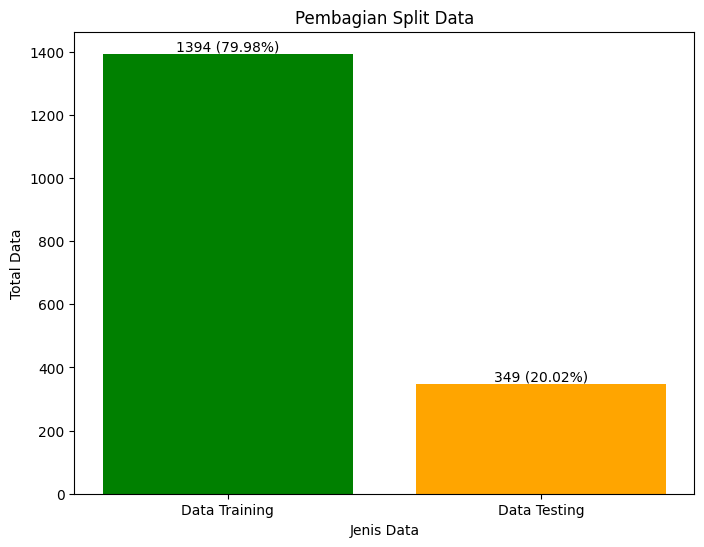

In [36]:
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

# Split Data
x_training, x_testing, y_training, y_testing = train_test_split(
    df['stemming'],
    df['sentiment'],
    test_size=0.20,
    random_state=42
)

# Simpan Ke Format CSV
data_training = pd.DataFrame({'text': x_training, 'sentiment': y_training})
data_training.to_csv('data_training.csv', index=False)

data_testing = pd.DataFrame({'text': x_testing, 'sentiment': y_testing})
data_testing.to_csv('data_testing.csv', index=False)

# Menghitung Jumlah Data Training & Testing
jumlah_training = len(data_training)
jumlah_testing = len(data_testing)

# Visualisasi Grafik
plt.figure(figsize=(8, 6))
colors = ['green', 'orange']
bars = plt.bar(['Data Training', 'Data Testing'], [jumlah_training, jumlah_testing], color=colors)

total = jumlah_training + jumlah_testing
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{int(height)} ({height / total * 100:.2f}%)',
             ha='center', va='bottom')

# Membuat Heatmap
plt.title('Pembagian Split Data')
plt.xlabel('Jenis Data')
plt.ylabel('Total Data')
plt.show()

## TF-IDF

In [82]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    token_pattern=r'(?u)\b[a-zA-Z]{2,}\b',
)

# Transform Data
tfidf_training = tfidf_vectorizer.fit_transform(x_training.astype(str))
tfidf_testing  = tfidf_vectorizer.transform(x_testing.astype(str))

# Hitung Rata-Rata TF-IDF
feature_names = tfidf_vectorizer.get_feature_names_out()
mean_tfidf = tfidf_training.mean(axis=0).A1

tfidf_df = pd.DataFrame({
    'kata': feature_names,
    'nilai_tfidf': mean_tfidf
})

# Filter Hapus Kata Tidak Penting
custom_stopwords = ['ya', 'yg', 'aja', 'nih', 'nya', 'layan']
tfidf_df = tfidf_df[~tfidf_df['kata'].isin(custom_stopwords)]

# Hapus Kata Terlalu Pendek
tfidf_df = tfidf_df[tfidf_df['kata'].str.len() > 2]

# Sortir Data
tfidf_sorted = tfidf_df.sort_values(by='nilai_tfidf', ascending=False)

# Tampilkan Top 20 Bobot Kata Tertinggi
print("\nTop 20 Kata TF-IDF:")
display(tfidf_sorted.head(20))

# Simpan & Download Otomatis File CSV
tfidf_sorted.to_csv('data_hasil_tfidf.csv', index=False)
print("\nFile Name data_hasil_tfidf.csv")
try:
    from google.colab import files
    files.download('data_hasil_tfidf.csv')
except:
    print("Download File Sukses")


Top 20 Kata TF-IDF:


,kata,nilai_tfidf
840,mudah,0.066854
140,bayar,0.058148
125,bantu,0.055039
952,pajak,0.052457
81,aplikasi,0.050448
242,cepat,0.048377
760,mantap,0.039929
1043,proses,0.039885
635,kirim,0.038282
1403,verifikasi,0.031318



File Name data_hasil_tfidf.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Cetak 10 Kata TF-IDF Tertinggi

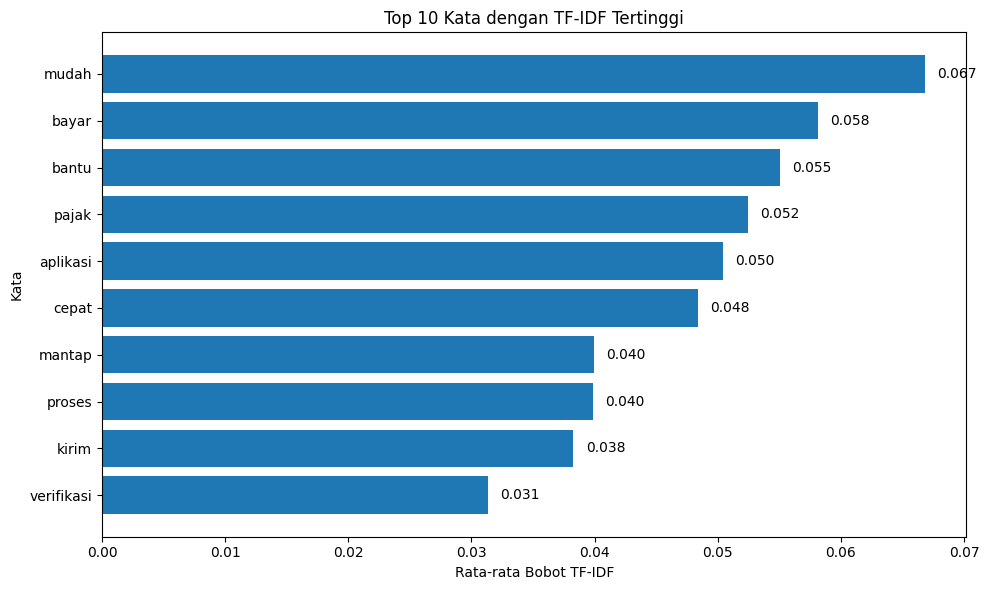

In [79]:
import numpy as np
import matplotlib.pyplot as plt

# Ambil Daftar Kata
feature_names = tfidf_vectorizer.get_feature_names_out()

# Hitung Rata-Rata TF-IDF Setiap Kata
mean_tfidf = tfidf_training.mean(axis=0).A1

# Buat DataFrame
tfidf_df = pd.DataFrame({
    'kata': feature_names,
    'nilai': mean_tfidf
})

# Ambil 10 Kata Nilai Tertinggi
top_n = tfidf_df.sort_values(by='nilai', ascending=False).head(10)

# Buat Heatmap
plt.figure(figsize=(10,6))
plt.barh(top_n['kata'], top_n['nilai'])
plt.gca().invert_yaxis()
plt.title('Top 10 Kata dengan TF-IDF Tertinggi')
plt.xlabel('Rata-rata Bobot TF-IDF')
plt.ylabel('Kata')
plt.show()

## Klasifikasi Model

### Naive Bayes

In [55]:
from sklearn.naive_bayes import MultinomialNB

# Latih Model Naive Bayes Dengan Data Training
nb = MultinomialNB()
nb.fit(tfidf_training, y_training)

# Prediksi Data Testing
y_pred = nb.predict(tfidf_testing)

### Decision Tree

In [56]:
from sklearn.tree import DecisionTreeClassifier

# Latih Model Decision Tree Dengan Data Training
tree = DecisionTreeClassifier(random_state=42)
tree.fit(tfidf_training, y_training)

# Prediksi Data Testing
y_pred_tree = tree.predict(tfidf_testing)

### Random Forest

In [57]:
from sklearn.ensemble import RandomForestClassifier

# Latih Model Random Forest Dengan Data Training
forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(tfidf_training, y_training)

# Prediksi Data Testing
y_pred_forest = forest.predict(tfidf_testing)

## Prediksi Algoritma

### Naive bayes

In [61]:
y_pred = nb.predict(tfidf_testing)

### Decision Tree

In [62]:
y_pred_tree = tree.predict(tfidf_testing)

### Random Forest

In [63]:
y_pred_forest = forest.predict(tfidf_testing)

## Evaluasi Algoritma

### Naive Bayes

In [73]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Naive Bayes
nb = MultinomialNB()
nb.fit(tfidf_training, y_training)
pred_nb = nb.predict(tfidf_testing)

print("Naive Bayes:")
print(f'Confusion Matrix\n {confusion_matrix(y_testing, pred_nb)}')
print('====================================================\n')
print(classification_report(y_testing, pred_nb, zero_division=0))

Naive Bayes:
Confusion Matrix
 [[ 18  33]
 [  4 294]]

              precision    recall  f1-score   support

     Negatif       0.82      0.35      0.49        51
     Positif       0.90      0.99      0.94       298

    accuracy                           0.89       349
   macro avg       0.86      0.67      0.72       349
weighted avg       0.89      0.89      0.88       349



#### Confussion Matrix Heatmap - Naive Bayes

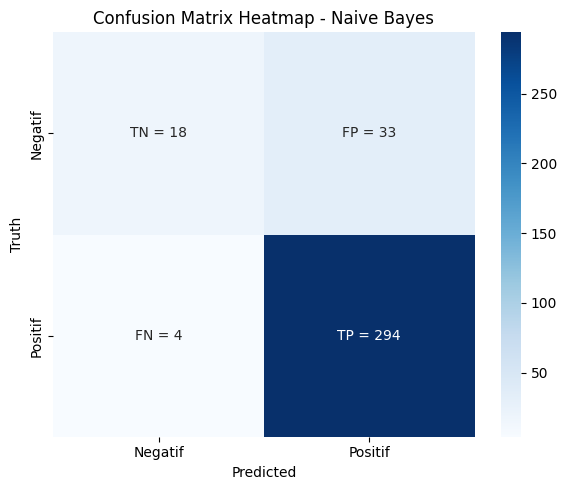

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Confusion Matrix Naive Bayes
matrix = confusion_matrix(y_testing, pred_nb)

# Konfigurasi Metrik
if matrix.shape == (2, 2):
    tn, fp, fn, tp = matrix.ravel()
    labels = np.array([
        [f"TN = {tn}", f"FP = {fp}"],
        [f"FN = {fn}", f"TP = {tp}"]
    ])
else:
    labels = matrix.astype(str)

# Membuat Heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(matrix, annot=labels, fmt="", cmap="Blues", cbar=True,
            xticklabels=np.unique(y_testing), yticklabels=np.unique(y_testing))

# Membuat Label
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.title("Confusion Matrix Heatmap - Naive Bayes")

plt.tight_layout()
plt.show()

### Decision Tree

In [72]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Decision Tree
tree = DecisionTreeClassifier(random_state=42)
tree.fit(tfidf_training, y_training)
pred_tree = tree.predict(tfidf_testing)

print("Decision Tree:")
print(f'Confusion Matrix\n {confusion_matrix(y_testing, pred_tree)}')
print('====================================================\n')
print(classification_report(y_testing, pred_tree, zero_division=0))

Decision Tree:
Confusion Matrix
 [[ 31  20]
 [ 26 272]]

              precision    recall  f1-score   support

     Negatif       0.54      0.61      0.57        51
     Positif       0.93      0.91      0.92       298

    accuracy                           0.87       349
   macro avg       0.74      0.76      0.75       349
weighted avg       0.87      0.87      0.87       349



#### Confussion Matrix Heatmap - Decision Tree

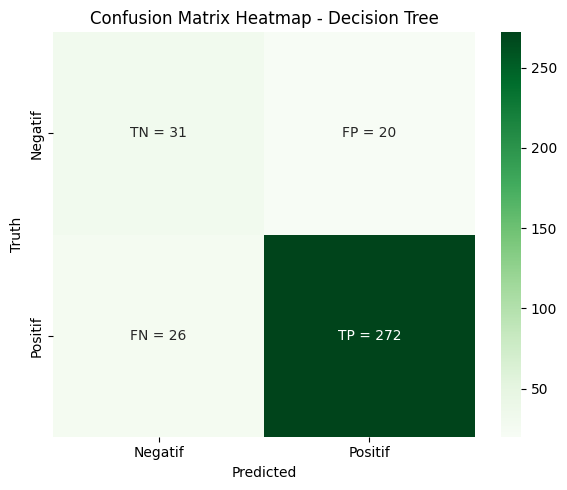

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Confusion Matrix Decision Tree
matrix = confusion_matrix(y_testing, pred_tree)

# Konfigurasi Metrik
if matrix.shape == (2, 2):
    tn, fp, fn, tp = matrix.ravel()
    labels = np.array([
        [f"TN = {tn}", f"FP = {fp}"],
        [f"FN = {fn}", f"TP = {tp}"]
    ])
else:
    labels = matrix.astype(str)

# Membuat Heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(matrix, annot=labels, fmt="", cmap="Greens", cbar=True,
            xticklabels=np.unique(y_testing), yticklabels=np.unique(y_testing))

# Membuat Label
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.title("Confusion Matrix Heatmap - Decision Tree")
plt.tight_layout()
plt.show()


### Random Forest

In [77]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(tfidf_training, y_training)
pred_forest = forest.predict(tfidf_testing)

# Random Forest
print("Random Forest:")
print(f'Confusion Matrix\n {confusion_matrix(y_testing, pred_forest)}')
print('====================================================\n')
print(classification_report(y_testing, pred_forest, zero_division=0))

Random Forest:
Confusion Matrix
 [[ 34  17]
 [  8 290]]

              precision    recall  f1-score   support

     Negatif       0.81      0.67      0.73        51
     Positif       0.94      0.97      0.96       298

    accuracy                           0.93       349
   macro avg       0.88      0.82      0.84       349
weighted avg       0.92      0.93      0.93       349



#### Confussion Matrix Heatmap - Random Forest

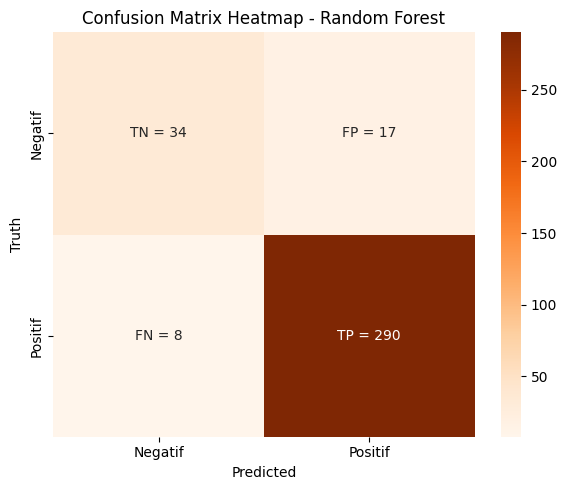

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Confusion Matrix Random Forest
conf_matrix = confusion_matrix(y_testing, pred_forest)

# Konfigurasi Metrik
if conf_matrix.shape == (2, 2):
    tn, fp, fn, tp = conf_matrix.ravel()
    labels = np.array([
        [f"TN = {tn}", f"FP = {fp}"],
        [f"FN = {fn}", f"TP = {tp}"]
    ])
else:
    labels = conf_matrix.astype(str)

# Membuat Heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=labels, fmt="", cmap="Oranges", cbar=True,
            xticklabels=np.unique(y_testing), yticklabels=np.unique(y_testing))

# Membuat Label
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.title("Confusion Matrix Heatmap - Random Forest")
plt.tight_layout()
plt.show()


## Visualisasi Data

### Wordcloud

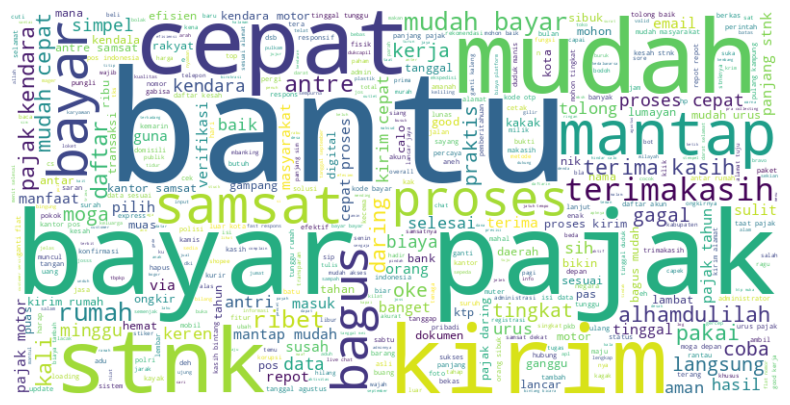

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

# Mengisi nilai NaN dengan string kosong ('')
df['stemming'] = df['stemming'].fillna('')

# Menggabungkan teks dari kolom 'content'
text = ' '.join(df['stemming'].astype(str).tolist())

wc = WordCloud(stopwords=stopwords, background_color="white", max_words=500, width=800, height=400)
wc.generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()


### Distribusi Rating

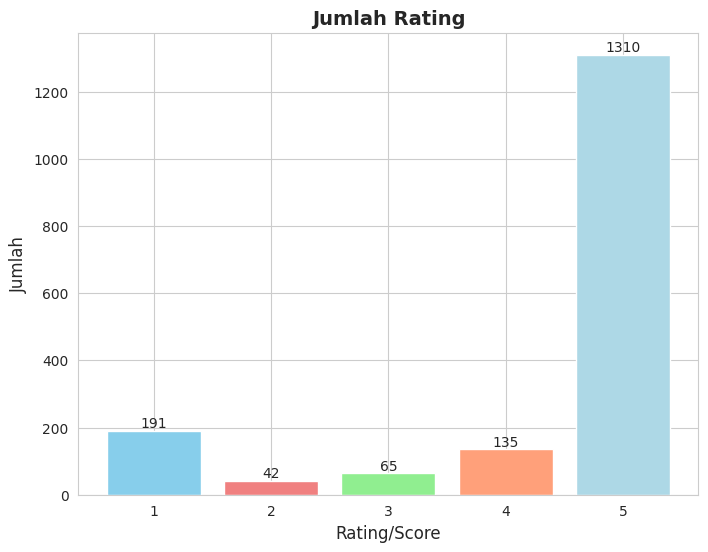

In [ ]:
import matplotlib.pyplot as plt

rating_counts = df['rating'].value_counts()
rating_counts = rating_counts.sort_index()

colors = ['skyblue', 'lightcoral', 'lightgreen', 'lightsalmon', 'lightblue']

plt.figure(figsize=(8, 6))
bars = plt.bar(rating_counts.index, rating_counts.values, color=colors)
plt.title('Jumlah Rating', fontsize=14, fontweight='bold')
plt.xlabel('Rating/Score', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
plt.xticks(rating_counts.index)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, str(int(height)), ha='center', va='bottom')

plt.show()


### Distribusi Sentimen

/tmp/ipython-input-396745411.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette=colors)


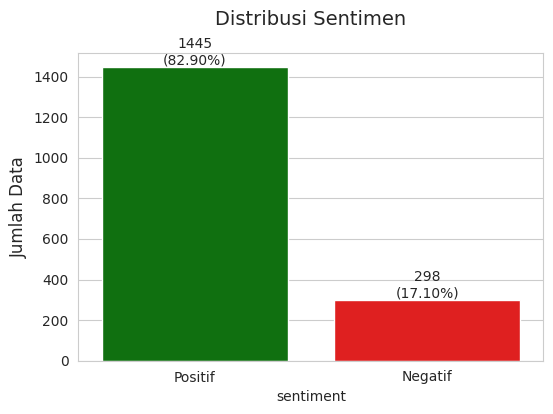

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Contoh: asumsi kolom 'Sentiment' berisi nilai 'Negatif' dan 'Positif'
sentiment_count = df['sentiment'].value_counts()
sns.set_style("whitegrid")

# Buat warna khusus berdasarkan label
colors = ['red' if label == 'Negatif' else 'green' for label in sentiment_count.index]

fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette=colors)
plt.title('Distribusi Sentimen', fontsize=14, pad=20)
plt.ylabel('Jumlah Data', fontsize=12)

total = len(df['sentiment'])

for i, count in enumerate(sentiment_count.values):
    percentage = f'{100 * count / total:.2f}%'
    ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom')

plt.show()
